In [1]:
from scipy.signal import butter, sosfilt, sosfilt_zi, sosfreqz
import numpy as np
from FixedPoint import FXnum, FXfamily
import matplotlib.pyplot as plt
import pandas as pd
import os  # used to save figures/ PDFs for Overleaf (cwd = this notebook's folder)


# Fixed-Point vs Floating-Point IIR Filter Implementation

## Overview
This notebook explores the **practical trade-offs** between fixed-point and floating-point data representations in digital signal processing (DSP). We compare 4 implementations of an IIR (Butterworth) lowpass filter:
- **2 Fixed-Point**: Q3.13 (3 integer + 13 fractional bits) and Q8.8 (8+8)
- **2 Floating-Point**: float32 and float16

**Goal**: Analyze errors (MSE, SNR), computational cost (timing), and memory footprint for each representation.


## Design the filter


In [2]:
sos = butter(4, 0.2, output='sos')  # 4th order, cutoff at 0.2*fs

Sos (second-order sections) format — it is more numerically stable than ba format and is the correct way to implement IIR in practice.


### Why SOS format?
Second-order sections (SOS) = more **numerically stable** than ba format. This is critical for IIR filters because cascading sections minimizes quantization errors and overflow risks—essential when comparing fixed vs floating point representations.


## Generate a test signal


In [3]:
fs = 1000        # sample rate
t = np.arange(0, 1, 1/fs)   # 1 second
# Mix of in-band (50 Hz) and out-of-band (300 Hz) tones
x = 0.5 * np.sin(2 * np.pi * 50 * t) + \
    0.5 * np.sin(2 * np.pi * 300 * t)

### Why this signal?
- **50 Hz component**: Should pass through (in-band, below cutoff at 100 Hz (−3 dB, Wn = 0.2 × Nyquist))
- **300 Hz component**: Should be filtered out (out-of-band, above cutoff)

This allows us to visually verify that each representation correctly filters the signal, regardless of quantization errors.


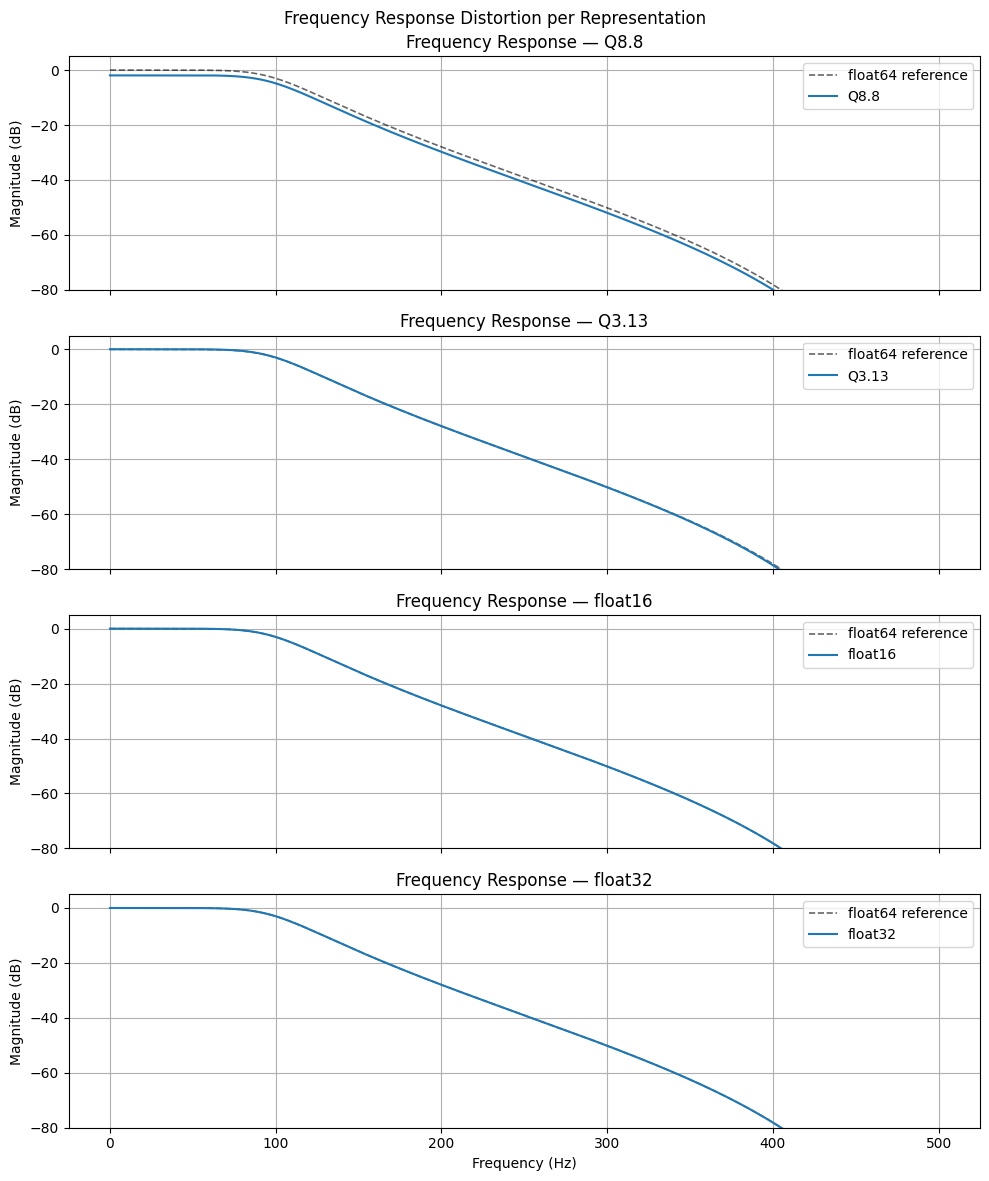

In [4]:
def quantize_sos(sos, n_int, n_frac, dtype=np.int16):
    """Quantize SOS coefficients with overflow detection."""
    scale     = 2**n_frac
    max_val   = (2**(n_int + n_frac - 1) - 1) / scale   # true int16 max
    min_val   = -2**(n_int + n_frac - 1)      / scale   # true int16 min

    coeffs = np.concatenate([sos[:, :3], sos[:, 4:]], axis=1)
    if np.any(coeffs > max_val) or np.any(coeffs < min_val):
        raise ValueError(
            f"Q{n_int}.{n_frac} overflow! "
            f"Coeff range [{coeffs.min():.4f}, {coeffs.max():.4f}] "
            f"exceeds [{min_val:.4f}, {max_val:.4f}]"
        )

    sos_q = np.round(sos * scale).astype(dtype) / scale
    sos_q[:, 3] = 1.0
    return sos_q

# ── Fixed-point ──────────────────────────────────────────────────────────────
sos_q313 = quantize_sos(sos, n_int=3, n_frac=13)   # replaces Q1.15
sos_q88  = quantize_sos(sos, n_int=8, n_frac=8)

# ── Floating-point ───────────────────────────────────────────────────────────
sos_f16       = sos.astype(np.float16); sos_f16[:, 3] = 1.0
sos_f32       = sos.astype(np.float32); sos_f32[:, 3] = 1.0

formats = [
    ("Q8.8",    sos_q88),
    ("Q3.13",   sos_q313),                        # ← was Q1.15
    ("float16", sos_f16.astype(np.float64)),
    ("float32", sos_f32.astype(np.float64)),
]

# ── Plot ─────────────────────────────────────────────────────────────────────
eps = 1e-12
w, H_ref = sosfreqz(sos, worN=8192, fs=fs)

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for ax, (name, sos_fmt) in zip(axes, formats):
    _, H = sosfreqz(sos_fmt, worN=8192, fs=fs)

    mag_ref = 20 * np.log10(np.maximum(np.abs(H_ref), eps))
    mag     = 20 * np.log10(np.maximum(np.abs(H),     eps))

    ax.plot(w, mag_ref, 'k--', linewidth=1.2, alpha=0.6, label='float64 reference')
    ax.plot(w, mag,     linewidth=1.5,                   label=name)
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(f'Frequency Response — {name}')
    ax.set_ylim(-80, 5)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel('Frequency (Hz)')
plt.suptitle('Frequency Response Distortion per Representation')
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/freq_response.pdf", bbox_inches="tight")
plt.show()


### Frequency Response Interpretation
- **Top plot**: Magnitude response in dB. Negative values = attenuation. The filter has ~3 dB at cutoff (100 Hz) and rolls off at ~80 dB/decade (4th order)
- **Bottom plot**: Phase response. Lower frequencies have minimal phase shift; higher frequencies show increasing phase lag

**Key**: All 4 implementations should exhibit similar frequency responses if quantization is acceptable.


Normalise so signal lives in [−1,1][-1, 1]
[−1,1] — signals are kept in a safe range for the fixed-point formats.


In [5]:
y_ref = sosfilt(sos, x.astype(np.float64))

In [6]:
def iir_sos_float16(sos, x):
    """
    IIR in second-order sections (direct form II). Coefficients, state,
    and each multiply/add are rounded to IEEE 754 binary16.
    SciPy sosfilt does not support float16; this is the usual workaround.
    """
    sos_h = sos.astype(np.float16)
    n_sec = sos_h.shape[0]
    w = np.zeros((n_sec, 2), dtype=np.float16)
    y_out = np.empty(len(x), dtype=np.float64)

    def q(z):
        return np.float16(z)

    for i, xn in enumerate(x):
        s = q(xn)
        for k in range(n_sec):
            b0, b1, b2, _a0, a1, a2 = sos_h[k]
            w0, w1 = w[k, 0], w[k, 1]
            v = q(q(s - q(a1 * w0)) - q(a2 * w1))
            y_sec = q(q(q(b0 * v) + q(b1 * w0)) + q(b2 * w1))
            w[k, 1] = w0
            w[k, 0] = v
            s = y_sec
        y_out[i] = float(s)
    return y_out


y_f32 = sosfilt(sos.astype(np.float32), x.astype(np.float32))
y_f16 = iir_sos_float16(sos, x)


In [7]:

def iir_fixed_point_spfpm(sos, x, n_frac):
    # Define the fixed-point family (fractional bits)
    family = FXfamily(n_frac)
    
    n_sections = sos.shape[0]
    
    # Quantise coefficients to fixed-point
    sos_q = [[FXnum(v, family) for v in section] for section in sos]
    
    # State registers: 2 delay elements per section
    w = [[FXnum(0, family), FXnum(0, family)] for _ in range(n_sections)]
    
    y = np.zeros(len(x))
    
    for i, sample in enumerate(x):
        s = FXnum(float(sample), family)
        
        for sec in range(n_sections):
            b0 = sos_q[sec][0]
            b1 = sos_q[sec][1]
            b2 = sos_q[sec][2]
            # a0 is always 1, skip it
            a1 = sos_q[sec][4]
            a2 = sos_q[sec][5]
            
            # Direct form II
            v = s - a1 * w[sec][0] - a2 * w[sec][1]
            out = b0 * v + b1 * w[sec][0] + b2 * w[sec][1]
            
            # Shift delay line
            w[sec][1] = w[sec][0]
            w[sec][0] = v
            
            s = out
        
        # Convert back to float for storage
        y[i] = float(s)
    
    return y

# Q3.13 — 13 fractional bits
y_q313 = iir_fixed_point_spfpm(sos, x, n_frac=13)

# Q8.8 — 8 fractional bits
y_q88  = iir_fixed_point_spfpm(sos, x, n_frac=8)

### Why Fixed-Point Implementation?
Fixed-point arithmetic is used in:
- **Embedded systems** (microcontrollers, DSPs) where floating-point hardware is unavailable/expensive
- **Real-time applications** requiring predictable latency
- **Power-constrained devices** (fixed-point ops use less power)

**Cost of quantization**: Lower bit-width = smaller range & precision loss, but lower power/area

**Trade-off**: Q3.13 uses more fractional bits than Q8.8 (same 16-bit word) but a smaller integer range.


In [8]:
def mse(ref, test):
    return np.mean((ref - test)**2)

def snr(ref, test):
    noise = mse(ref, test)
    if noise == 0:
        return float('inf')
    return 10 * np.log10(np.var(ref) / noise)

results = {
    'Q3.13':   y_q313,  # ← was Q1.15
    'Q8.8':    y_q88,
    'float16': y_f16,
    'float32': y_f32,
}

print(f"{'Format':<12} {'MSE':>14} {'SNR (dB)':>10}")
print("-" * 38)
for name, y in results.items():
    m = mse(y_ref, y)
    s = snr(y_ref, y)
    print(f"{name:<12} {m:>14.6e} {s:>10.2f}")

Format                  MSE   SNR (dB)
--------------------------------------
Q3.13          4.037034e-06      44.87
Q8.8           5.123259e-03      13.84
float16        5.314039e-07      53.68
float32        2.711132e-15     136.60


## Error Analysis: MSE & SNR

**Metrics**:
- **MSE** (Mean Squared Error): Quantifies how much each implementation deviates from float64 reference
- **SNR** (Signal-to-Noise Ratio): Ratio of signal power to quantization noise power in dB

**What to look for**:
- Q3.13 should outperform Q8.8 on this filter (more fractional bits; better coefficient fit)
- Q8.8 trades precision for wider dynamic range → higher error
- float32 should be very close to reference (minor rounding)
- float16 expected to show noticeable noise (only 10-bit precision)


t_plot shape: (1000,)


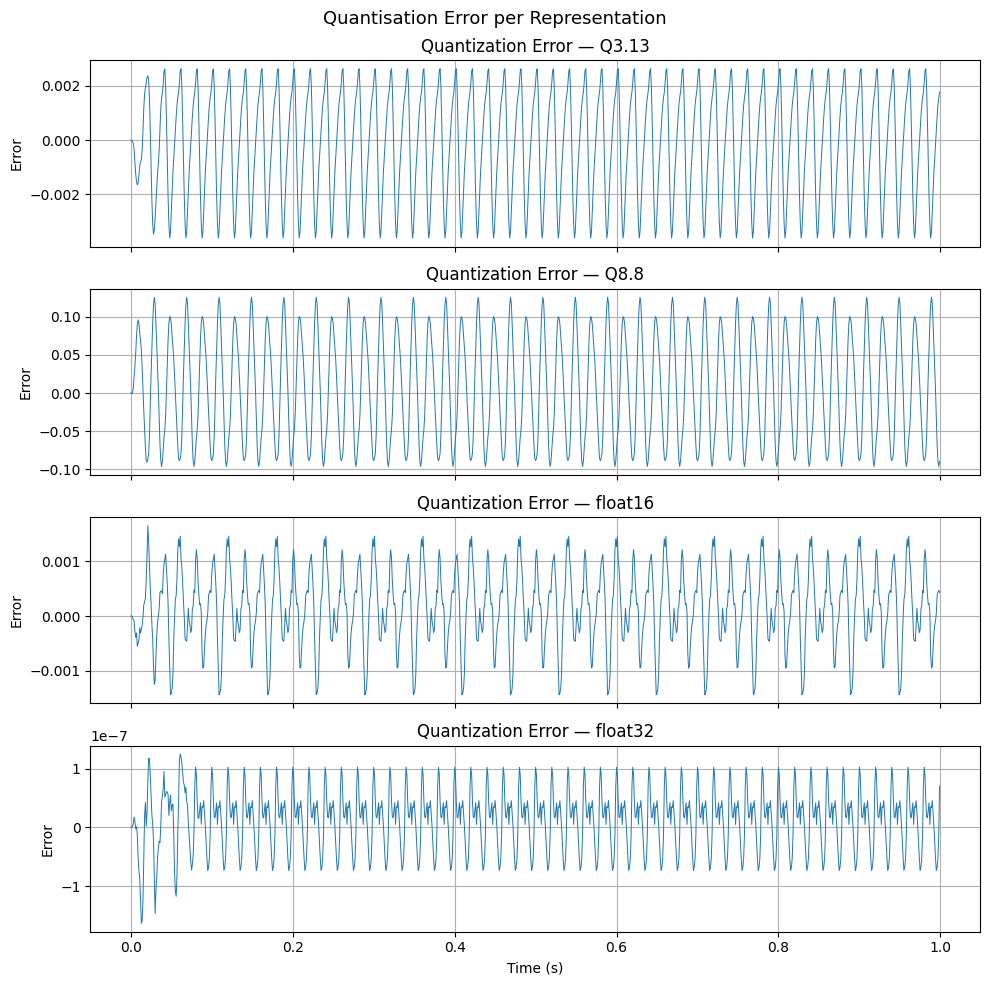

In [9]:
N = len(y_ref)
t_plot = np.linspace(0, N/fs, N, endpoint=False)  # use t_plot, not t
                                                    # avoids overwriting t again

print(f"t_plot shape: {t_plot.shape}")  # should be (1000,)

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

for ax, (name, y) in zip(axes, results.items()):
    y       = np.asarray(y)
    min_len = min(len(t_plot), len(y_ref), len(y))
    error   = y_ref[:min_len] - y[:min_len]

    ax.plot(t_plot[:min_len], error, linewidth=0.7)
    ax.set_title(f'Quantization Error — {name}')
    ax.set_ylabel('Error')
    ax.grid(True)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Quantisation Error per Representation', fontsize=13)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/error_per_format.pdf", bbox_inches="tight")
plt.show()


## Quantization Error Visualization
The plots show the **error per sample** (reference - quantized output) over time. This reveals:
- **Periodicity**: Fixed-point errors are often periodic (due to rounding artifacts)
- **Amplitude**: Q3.13 errors should be smaller than Q8.8; Q8.8 may be largest among fixed-point
- **Consistency**: Compare which formats have stable vs. growing error


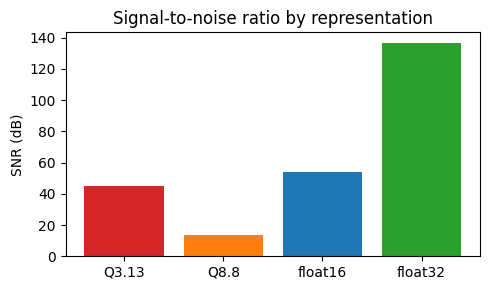

In [10]:
names = list(results.keys())
snrs  = [snr(y_ref, y) for y in results.values()]

plt.figure(figsize=(5, 3))
bars = plt.bar(names, snrs, color=['#d62728','#ff7f0e','#1f77b4','#2ca02c'])
plt.ylabel('SNR (dB)')
plt.title('Signal-to-noise ratio by representation')
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/snr_bar.pdf", bbox_inches="tight")
plt.show()


## SNR Comparison
Higher SNR = **better representation fidelity**. Clearly shows the trade-off:
- **Q3.13**: Stronger SNR among the 16-bit fixed options for this coefficient set
- **float32**: Excellent SNR (IEEE 754 precision)
- **float16**: Lower SNR (limited mantissa bits)
- **Q8.8**: May be lower depending on overflow/underflow behavior


In [11]:
import time

timings = {}

# float64 reference
start = time.perf_counter()
for _ in range(100):
    sosfilt(sos, x.astype(np.float64))
timings['float64'] = (time.perf_counter() - start) / 100

# float32
start = time.perf_counter()
for _ in range(100):
    sosfilt(sos.astype(np.float32), x.astype(np.float32))
timings['float32'] = (time.perf_counter() - start) / 100

# float16 (sample-by-sample half precision)
start = time.perf_counter()
for _ in range(100):
    iir_sos_float16(sos, x)
timings['float16'] = (time.perf_counter() - start) / 100

# Q3.13
start = time.perf_counter()
for _ in range(100):
    iir_fixed_point_spfpm(sos, x, n_frac=13)
timings['Q3.13'] = (time.perf_counter() - start) / 100

# Q8.8
start = time.perf_counter()
for _ in range(100):
    iir_fixed_point_spfpm(sos, x, n_frac=8)
timings['Q8.8'] = (time.perf_counter() - start) / 100

print(f"\n{'Format':<12} {'Time (ms)':>12}")
print("-" * 26)
for name, t in timings.items():
    print(f"{name:<12} {t*1000:>12.4f}")



Format          Time (ms)
--------------------------
float64            0.0761
float32            0.0627
float16            9.8038
Q3.13             17.7948
Q8.8              17.1664


## Computational Cost Analysis

**Why timing matters**:
- **Fixed-point**: Generally faster on systems without FPU (Floating-Point Unit)
- **float32/float16**: Hardware-accelerated on modern CPUs/GPUs, may be faster than custom fixed-point code
- **Python overhead**: Our fixed-point implementation (Python loop) is slower than scipy's optimized `sosfilt()`, but shows the concept

**Real-world**: Compare on embedded systems (ARM Cortex-M, RISC-V) for true timing differences


In [12]:
import sys

memory = {}
memory['float64'] = x.astype(np.float64).nbytes
memory['float32'] = x.astype(np.float32).nbytes
memory['float16'] = x.astype(np.float16).nbytes
# Fixed-point stored as int16
memory['Q3.13'] = x.astype(np.int16).nbytes
memory['Q8.8']  = x.astype(np.int16).nbytes

print(f"\n{'Format':<12} {'Memory (bytes)':>15}")
print("-" * 28)
for name, m in memory.items():
    print(f"{name:<12} {m:>15}")


Format        Memory (bytes)
----------------------------
float64                 8000
float32                 4000
float16                 2000
Q3.13                   2000
Q8.8                    2000


In [13]:
order = ['Q8.8', 'Q3.13', 'float16', 'float32']
types = ['Fixed', 'Fixed', 'Float', 'Float']
bits = ['16 (8+8)', '16 (3+13)', '16', '32']
lsb = ['3.9e-3', '1.2e-4', '~1e-3 rel', '~1e-7 rel']

rows = []
for k, ty, b, eps in zip(order, types, bits, lsb):
    m = mse(y_ref, results[k])
    s = snr(y_ref, results[k])
    rows.append(
        {
            'Format': k,
            'Type': ty,
            'Bits': b,
            'LSB/Eps': eps,
            'MSE': f'{m:.4e}',
            'SNR (dB)': f'{s:.2f}',
        }
    )

df = pd.DataFrame(rows)
print(df.to_string(index=False))


 Format  Type      Bits   LSB/Eps        MSE SNR (dB)
   Q8.8 Fixed  16 (8+8)    3.9e-3 5.1233e-03    13.84
  Q3.13 Fixed 16 (3+13)    1.2e-4 4.0370e-06    44.87
float16 Float        16 ~1e-3 rel 5.3140e-07    53.68
float32 Float        32 ~1e-7 rel 2.7111e-15   136.60


## Memory Footprint Analysis

**Data storage per signal sample**:
- **float64**: 8 bytes (baseline reference)
- **float32**: 4 bytes (50% reduction)
- **float16**: 2 bytes (75% reduction)
- **Q3.13 & Q8.8**: 2 bytes each (stored as int16, 75% reduction)

**Memory savings matter for**:
- **Embedded systems** with limited RAM (e.g., microcontrollers)
- **Real-time buffering** of large signals
- **Cache efficiency** in signal processing pipelines

### Q2: Observed Errors
Results table shows:
- **Q3.13**: Much lower MSE than Q8.8 for this IIR (fractional bit allocation)
- **Q8.8**: Higher MSE, lower SNR → fewer fractional bits reduce precision
- **float32**: Similar to float64 → hardware precision sufficient
- **float16**: Visible noise but acceptable for some applications → trade-off for memory
